Logistic Regression Visualization

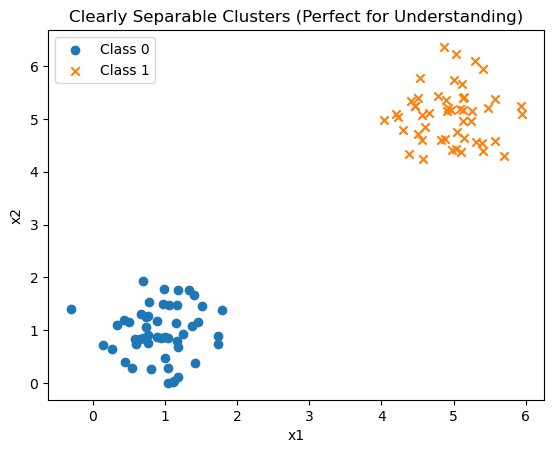

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Two clear clusters
np.random.seed(42)

class0 = np.random.randn(50, 2) * 0.5 + np.array([1, 1])   # cluster near (1,1)
class1 = np.random.randn(50, 2) * 0.5 + np.array([5, 5])   # cluster near (5,5)

X = np.vstack([class0, class1])
y = np.array([0]*50 + [1]*50)

# Visualize
plt.scatter(class0[:,0], class0[:,1], marker='o', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], marker='x', label='Class 1')
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Clearly Separable Clusters (Perfect for Understanding)")
plt.show()

In [9]:
m = X.shape[0]
X = np.c_[np.ones(m), X]
print("X shape:", X.shape)

X shape: (100, 3)


In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def f(X, w):
    return sigmoid(X @ w)

def J(preds, y):
    m = len(y)
    epsilon = 1e-9
    return -(1/m) * np.sum(y*np.log(preds + epsilon) + (1-y)*np.log(1 - preds + epsilon))

In [11]:
w = np.zeros(X.shape[1])
alpha = 0.1
epochs = 1000
costs = []
epsilon = 1e-6

In [12]:
previous_cost = float('inf')

for i in range(epochs):
    preds = f(X, w)

    gradient = (1/m) * (X.T @ (preds - y))
    w = w - alpha * gradient

    cost = J(preds, y)
    costs.append(cost)

    diff = abs(previous_cost - cost)
    previous_cost = cost

    if diff < epsilon:
        print("Converged at iteration:", i+1)
        break

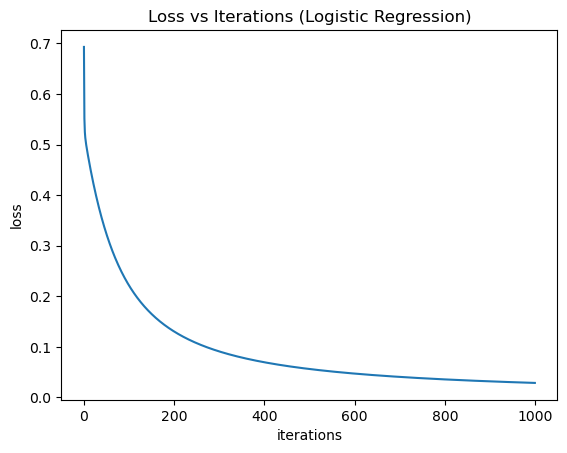

In [13]:
plt.plot(costs)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.title("Loss vs Iterations (Logistic Regression)")
plt.show()

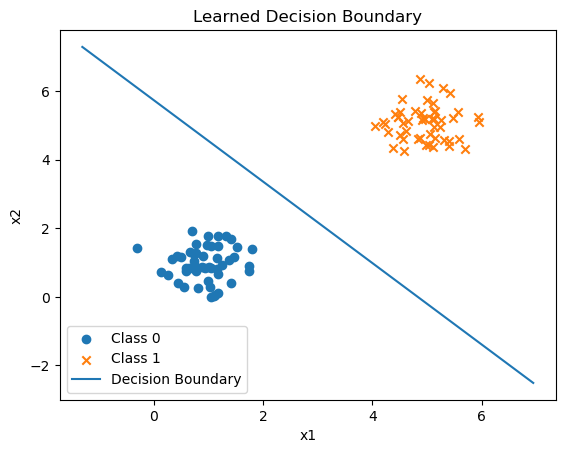

In [14]:
x1_vals = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
x2_vals = -(w[0] + w[1]*x1_vals) / w[2]

plt.scatter(X[y==0][:,1], X[y==0][:,2], marker='o', label='Class 0')
plt.scatter(X[y==1][:,1], X[y==1][:,2], marker='x', label='Class 1')
plt.plot(x1_vals, x2_vals, label="Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Learned Decision Boundary")
plt.show()